# EMG-Based Lower Limb Movement Classification Using Random Forest

## Objective

The objective of this project is to classify lower-limb movements using
Electromyography (EMG) signals. The system classifies EMG recordings into
three movement classes:

- Leg Down
- Leg Move
- Leg Up

The EMG signals are preprocessed, divided into fixed-length windows,
converted into time-domain features, and classified using a Random Forest
machine learning model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import detrend

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import joblib

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Files uploaded:")
for filename in uploaded.keys():
    print(filename)

Saving Electromyography Signal Dataset for Controlling Lower Limb Prostheses.xlsx to Electromyography Signal Dataset for Controlling Lower Limb Prostheses (3).xlsx
Files uploaded:
Electromyography Signal Dataset for Controlling Lower Limb Prostheses (3).xlsx


In [ ]:
import os

print("Uploaded files:")
for file in os.listdir():
    print(file)

Uploaded files:
.config
Electromyography Signal Dataset for Controlling Lower Limb Prostheses.xlsx
Electromyography Signal Dataset for Controlling Lower Limb Prostheses (3).xlsx
Electromyography Signal Dataset for Controlling Lower Limb Prostheses (2).xlsx
Electromyography Signal Dataset for Controlling Lower Limb Prostheses (1).xlsx
final_emg_random_forest.pkl
emg_feature_names.pkl
sample_data


In [ ]:
import os
import pandas as pd

excel_files = [
    f for f in os.listdir()
    if f.lower().endswith(".xlsx")
]

for file in excel_files:
    print("\n" + "=" * 70)
    print("FILE:", file)

    xls = pd.ExcelFile(file)
    print("Sheets:", xls.sheet_names)

    for sheet in xls.sheet_names:
        df = pd.read_excel(file, sheet_name=sheet)
        print(f"\n  Sheet: {sheet}")
        print("  Shape:", df.shape)
        print("  Columns:", list(df.columns))
        print(df.head(2))


FILE: Electromyography Signal Dataset for Controlling Lower Limb Prostheses.xlsx
Sheets: ['leg down', 'leg up', 'leg move']

  Sheet: leg down
  Shape: (110874, 1)
  Columns: [6]
   6
0  8
1  5

  Sheet: leg up
  Shape: (13308, 1)
  Columns: [51]
   51
0  22
1  50

  Sheet: leg move
  Shape: (37558, 1)
  Columns: [77]
   77
0  76
1  64

FILE: Electromyography Signal Dataset for Controlling Lower Limb Prostheses (3).xlsx
Sheets: ['leg down', 'leg up', 'leg move']

  Sheet: leg down
  Shape: (110874, 1)
  Columns: [6]
   6
0  8
1  5

  Sheet: leg up
  Shape: (13308, 1)
  Columns: [51]
   51
0  22
1  50

  Sheet: leg move
  Shape: (37558, 1)
  Columns: [77]
   77
0  76
1  64

FILE: Electromyography Signal Dataset for Controlling Lower Limb Prostheses (2).xlsx
Sheets: ['leg down', 'leg up', 'leg move']

  Sheet: leg down
  Shape: (110874, 1)
  Columns: [6]
   6
0  8
1  5

  Sheet: leg up
  Shape: (13308, 1)
  Columns: [51]
   51
0  22
1  50

  Sheet: leg move
  Shape: (37558, 1)
  Columns

In [ ]:
# Load the original dataset

file_path = "Electromyography Signal Dataset for Controlling Lower Limb Prostheses.xlsx"

leg_down = pd.read_excel(file_path, sheet_name="leg down").iloc[:, 0].to_numpy()
leg_up = pd.read_excel(file_path, sheet_name="leg up").iloc[:, 0].to_numpy()
leg_move = pd.read_excel(file_path, sheet_name="leg move").iloc[:, 0].to_numpy()

print("Dataset loaded successfully.\n")

print("Leg Down :", len(leg_down), "samples")
print("Leg Up   :", len(leg_up), "samples")
print("Leg Move :", len(leg_move), "samples")

Dataset loaded successfully.

Leg Down : 110874 samples
Leg Up   : 13308 samples
Leg Move : 37558 samples


In [ ]:
# Load the original EMG dataset correctly

file_path = "Electromyography Signal Dataset for Controlling Lower Limb Prostheses.xlsx"

# header=None preserves the first EMG sample
leg_down = pd.read_excel(
    file_path, sheet_name="leg down", header=None
).iloc[:, 0]

leg_up = pd.read_excel(
    file_path, sheet_name="leg up", header=None
).iloc[:, 0]

leg_move = pd.read_excel(
    file_path, sheet_name="leg move", header=None
).iloc[:, 0]

# Convert values to numeric
leg_down = pd.to_numeric(leg_down, errors="coerce").to_numpy()
leg_up = pd.to_numeric(leg_up, errors="coerce").to_numpy()
leg_move = pd.to_numeric(leg_move, errors="coerce").to_numpy()

print("Dataset loaded successfully.\n")

print("Leg Down :", len(leg_down), "samples")
print("Leg Up   :", len(leg_up), "samples")
print("Leg Move  :", len(leg_move), "samples")

print("\nMissing values:")
print("Leg Down :", np.isnan(leg_down).sum())
print("Leg Up   :", np.isnan(leg_up).sum())
print("Leg Move :", np.isnan(leg_move).sum())

print("\nFirst 10 samples:")
print("Leg Down:", leg_down[:10])
print("Leg Up  :", leg_up[:10])
print("Leg Move:", leg_move[:10])

Dataset loaded successfully.

Leg Down : 110875 samples
Leg Up   : 13309 samples
Leg Move  : 37559 samples

Missing values:
Leg Down : 314
Leg Up   : 41
Leg Move : 112

First 10 samples:
Leg Down: [ 6.  8.  5. 17.  3. 23. 20. 15. 96.  2.]
Leg Up  : [51. 22. 50. 31. 56. 52. 36. 38. 24. 34.]
Leg Move: [ 77.  76.  64.  50.   5.   5.   4. 110. 104.  39.]


## Methodology

The proposed system follows the following pipeline:

Raw EMG Dataset
↓
Signal Preprocessing
↓
Fixed-Length Windowing
↓
EMG Feature Extraction
↓
Train/Test Split
↓
Random Forest Training
↓
Model Evaluation
↓
Movement Prediction

### Preprocessing

The raw EMG signals are converted into numerical arrays. Invalid values
such as NaN and infinite values are handled using interpolation. The
signals are then detrended to remove baseline/DC components and full-wave
rectified using the absolute value.

### Windowing

The preprocessed signals are divided into fixed-length windows of
200 samples.

### Feature Extraction

Seven time-domain EMG features are extracted from each window:

1. Mean Absolute Value (MAV)
2. Root Mean Square (RMS)
3. Variance
4. Waveform Length
5. Zero Crossings
6. Slope Sign Changes
7. Willison Amplitude

### Classification

A Random Forest classifier is trained using the extracted EMG features
to classify the three lower-limb movement classes.

In [ ]:
# ==========================================
# EMG SIGNAL PREPROCESSING
# ==========================================

from scipy.signal import detrend

def preprocess_emg(signal):
    signal = np.asarray(signal, dtype=float)

    # Convert infinite values to NaN
    signal[~np.isfinite(signal)] = np.nan

    # Fill missing values using linear interpolation
    signal_series = pd.Series(signal)
    signal_series = signal_series.interpolate(
        method="linear",
        limit_direction="both"
    )

    # If anything is still missing, replace with the median
    signal_series = signal_series.fillna(signal_series.median())

    signal = signal_series.to_numpy()

    # Remove baseline/DC component
    signal_detrended = detrend(signal)

    # Full-wave rectification
    signal_rectified = np.abs(signal_detrended)

    return signal_rectified


# Apply preprocessing
leg_down_processed = preprocess_emg(leg_down)
leg_up_processed = preprocess_emg(leg_up)
leg_move_processed = preprocess_emg(leg_move)


print("Preprocessing completed successfully.")

print("\nProcessed signal lengths:")
print("Leg Down :", len(leg_down_processed))
print("Leg Up   :", len(leg_up_processed))
print("Leg Move :", len(leg_move_processed))

print("\nChecking for remaining invalid values:")
print("Leg Down NaN:", np.isnan(leg_down_processed).sum())
print("Leg Up NaN  :", np.isnan(leg_up_processed).sum())
print("Leg Move NaN:", np.isnan(leg_move_processed).sum())

Preprocessing completed successfully.

Processed signal lengths:
Leg Down : 110875
Leg Up   : 13309
Leg Move : 37559

Checking for remaining invalid values:
Leg Down NaN: 0
Leg Up NaN  : 0
Leg Move NaN: 0


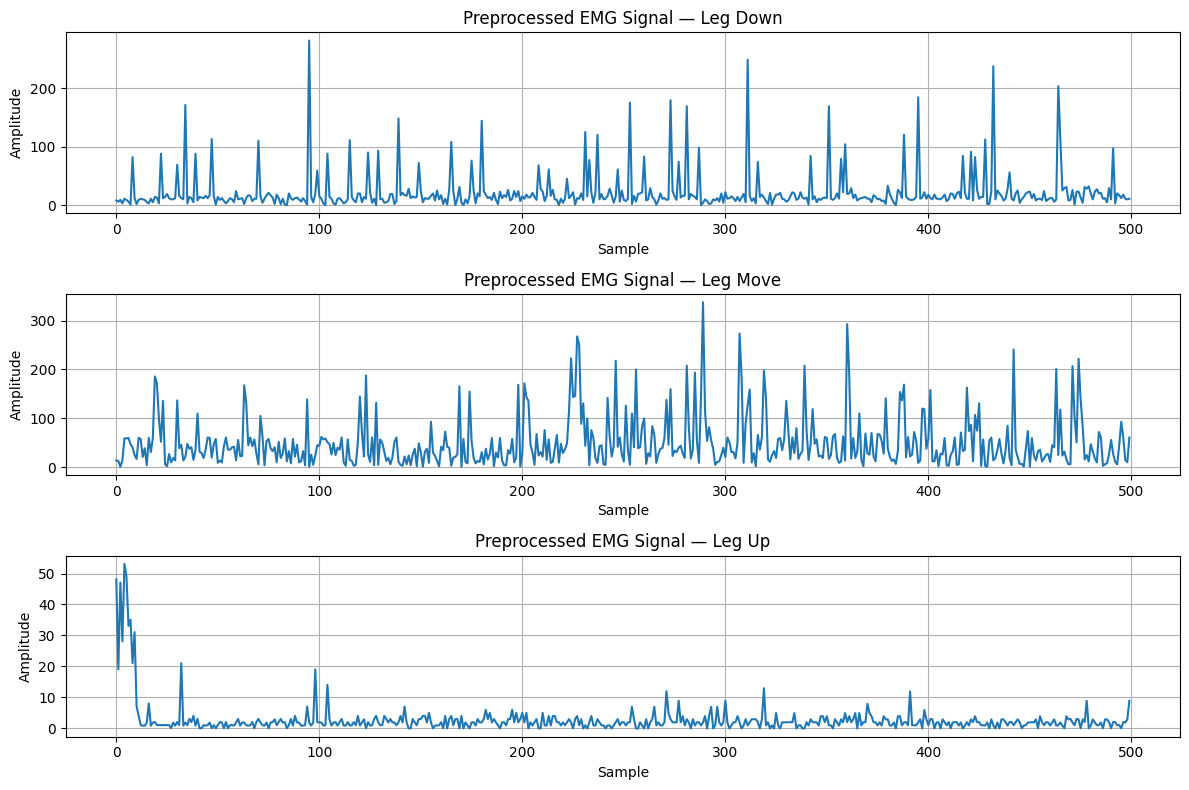

In [ ]:
# ==========================================
# VISUALIZE PREPROCESSED EMG SIGNALS
# ==========================================

plt.figure(figsize=(12, 8))

signals = [
    ("Leg Down", leg_down_processed),
    ("Leg Move", leg_move_processed),
    ("Leg Up", leg_up_processed)
]

for i, (label, signal) in enumerate(signals):

    plt.subplot(3, 1, i + 1)

    # Show first 500 samples for readability
    plt.plot(signal[:500])

    plt.title(f"Preprocessed EMG Signal — {label}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# CREATE FIXED-LENGTH EMG WINDOWS
# ==========================================

WINDOW_SIZE = 200

def create_windows(signal, window_size=200):
    n_windows = len(signal) // window_size

    windows = []

    for i in range(n_windows):
        start = i * window_size
        end = start + window_size
        windows.append(signal[start:end])

    return np.array(windows)


# Create windows for each movement
down_windows = create_windows(leg_down_processed, WINDOW_SIZE)
up_windows = create_windows(leg_up_processed, WINDOW_SIZE)
move_windows = create_windows(leg_move_processed, WINDOW_SIZE)


print("Windowing completed.\n")

print("Leg Down windows:", down_windows.shape)
print("Leg Up windows  :", up_windows.shape)
print("Leg Move windows:", move_windows.shape)

Windowing completed.

Leg Down windows: (554, 200)
Leg Up windows  : (66, 200)
Leg Move windows: (187, 200)


In [ ]:
# Combine all movement classes

X = np.vstack([
    down_windows,
    move_windows,
    up_windows
])

y = np.concatenate([
    np.full(len(down_windows), "Leg Down"),
    np.full(len(move_windows), "Leg Move"),
    np.full(len(up_windows), "Leg Up")
])

print("Combined dataset shape:", X.shape)
print("Labels shape:", y.shape)

print("\nClass distribution:")
print(pd.Series(y).value_counts())

Combined dataset shape: (807, 200)
Labels shape: (807,)

Class distribution:
Leg Down    554
Leg Move    187
Leg Up       66
Name: count, dtype: int64


In [ ]:
# ==========================================
# EMG FEATURE EXTRACTION
# ==========================================

def extract_features(signal):
    signal = np.asarray(signal, dtype=float)

    # 1. Mean Absolute Value
    mav = np.mean(np.abs(signal))

    # 2. Root Mean Square
    rms = np.sqrt(np.mean(signal ** 2))

    # 3. Variance
    variance = np.var(signal)

    # 4. Waveform Length
    waveform_length = np.sum(np.abs(np.diff(signal)))

    # 5. Zero Crossings
    zero_crossings = np.sum(
        (signal[:-1] * signal[1:]) < 0
    )

    # 6. Slope Sign Changes
    diff_signal = np.diff(signal)
    slope_sign_changes = np.sum(
        (diff_signal[:-1] * diff_signal[1:]) < 0
    )

    # 7. Willison Amplitude
    threshold = 0.01 * np.std(signal)
    willison_amplitude = np.sum(
        np.abs(np.diff(signal)) > threshold
    )

    return [
        mav,
        rms,
        variance,
        waveform_length,
        zero_crossings,
        slope_sign_changes,
        willison_amplitude
    ]


# Extract features from every window
feature_data = np.array([
    extract_features(window)
    for window in X
])


feature_names = [
    "MAV",
    "RMS",
    "Variance",
    "Waveform_Length",
    "Zero_Crossings",
    "Slope_Sign_Changes",
    "Willison_Amplitude"
]

feature_df = pd.DataFrame(
    feature_data,
    columns=feature_names
)

print("Feature extraction completed.")
print("Feature dataset shape:", feature_df.shape)

display(feature_df.head())

Feature extraction completed.
Feature dataset shape: (807, 7)


,MAV,RMS,Variance,Waveform_Length,Zero_Crossings,Slope_Sign_Changes,Willison_Amplitude
0,20.237621,38.520548,1074.271349,4700.412080,0.0,128.0,194.0
1,23.362610,42.876370,1292.571549,5363.838386,0.0,128.0,195.0
2,25.734643,45.452996,1403.703005,5342.630189,0.0,132.0,188.0
3,24.242923,38.714803,911.116626,5111.580727,0.0,132.0,190.0
4,23.419071,38.003961,895.848156,4441.482634,0.0,118.0,190.0


In [ ]:
# ==========================================
# PREPARE DATA FOR MACHINE LEARNING
# ==========================================

X_features = feature_df.values
y_labels = y

print("Feature matrix shape:", X_features.shape)
print("Label vector shape:", y_labels.shape)

print("\nFeatures:")
print(feature_names)

print("\nClass distribution:")
print(pd.Series(y_labels).value_counts())

Feature matrix shape: (807, 7)
Label vector shape: (807,)

Features:
['MAV', 'RMS', 'Variance', 'Waveform_Length', 'Zero_Crossings', 'Slope_Sign_Changes', 'Willison_Amplitude']

Class distribution:
Leg Down    554
Leg Move    187
Leg Up       66
Name: count, dtype: int64


In [ ]:
# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_labels,
    test_size=0.20,
    random_state=42,
    stratify=y_labels
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training samples: 645
Testing samples : 162

Training class distribution:
Leg Down    443
Leg Move    149
Leg Up       53
Name: count, dtype: int64

Testing class distribution:
Leg Down    111
Leg Move     38
Leg Up       13
Name: count, dtype: int64


In [ ]:
# ==========================================
# RANDOM FOREST CLASSIFIER
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")
print("Number of trees:", rf_model.n_estimators)

Random Forest trained successfully!
Number of trees: 300


In [ ]:
# ==========================================
# MODEL EVALUATION
# ==========================================

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Test Accuracy :", f"{accuracy:.4f}")
print("Test Macro F1 :", f"{macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=["Leg Down", "Leg Move", "Leg Up"],
        zero_division=0
    )
)

Test Accuracy : 0.9444
Test Macro F1 : 0.8491

Classification Report:
              precision    recall  f1-score   support

    Leg Down       0.94      0.98      0.96       111
    Leg Move       0.97      1.00      0.99        38
      Leg Up       0.86      0.46      0.60        13

    accuracy                           0.94       162
   macro avg       0.92      0.81      0.85       162
weighted avg       0.94      0.94      0.94       162



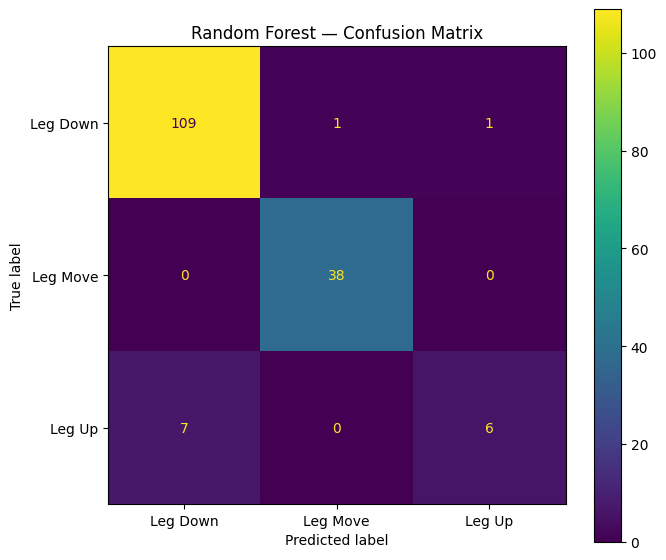

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

labels = ["Leg Down", "Leg Move", "Leg Up"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="viridis",
    values_format="d"
)

plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

Feature Importance:


,Feature,Importance
0,MAV,0.277211
1,Waveform_Length,0.198311
2,RMS,0.188567
3,Variance,0.148739
4,Willison_Amplitude,0.142619
5,Slope_Sign_Changes,0.044553
6,Zero_Crossings,0.000000


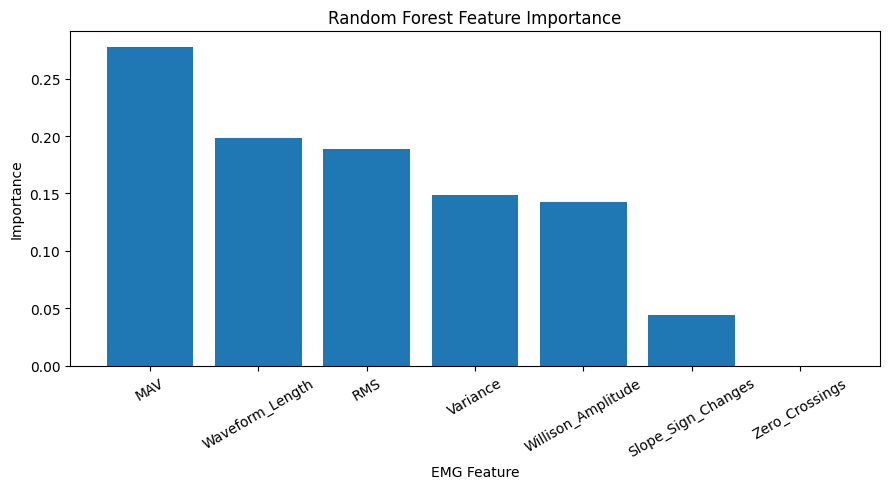

In [ ]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Feature Importance:")
display(feature_importance)

# Plot
plt.figure(figsize=(9, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("EMG Feature")
plt.ylabel("Importance")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SAVE FINAL MODEL
# ==========================================

import joblib

# Save trained Random Forest
joblib.dump(rf_model, "final_emg_random_forest.pkl")

# Save feature order
joblib.dump(feature_names, "emg_feature_names.pkl")

print("Final model saved successfully.")
print("Feature configuration saved successfully.")

Final model saved successfully.
Feature configuration saved successfully.


In [ ]:
# ==========================================
# FINAL MODEL PREDICTION DEMO
# ==========================================

# Select a few test samples
num_samples = 5

sample_X = X_test[:num_samples]
sample_y = y_test[:num_samples]

# Predict classes
predictions = rf_model.predict(sample_X)

# Prediction probabilities
probabilities = rf_model.predict_proba(sample_X)

print("FINAL MODEL PREDICTION DEMO\n")

for i in range(num_samples):
    print(f"Sample {i + 1}")
    print("Actual movement   :", sample_y[i])
    print("Predicted movement:", predictions[i])

    print("Probabilities:")
    for class_name, probability in zip(
        rf_model.classes_,
        probabilities[i]
    ):
        print(f"  {class_name}: {probability:.3f}")

    print("-" * 40)

FINAL MODEL PREDICTION DEMO

Sample 1
Actual movement   : Leg Down
Predicted movement: Leg Down
Probabilities:
  Leg Down: 0.967
  Leg Move: 0.027
  Leg Up: 0.007
----------------------------------------
Sample 2
Actual movement   : Leg Move
Predicted movement: Leg Move
Probabilities:
  Leg Down: 0.007
  Leg Move: 0.993
  Leg Up: 0.000
----------------------------------------
Sample 3
Actual movement   : Leg Move
Predicted movement: Leg Move
Probabilities:
  Leg Down: 0.007
  Leg Move: 0.993
  Leg Up: 0.000
----------------------------------------
Sample 4
Actual movement   : Leg Down
Predicted movement: Leg Down
Probabilities:
  Leg Down: 0.973
  Leg Move: 0.000
  Leg Up: 0.027
----------------------------------------
Sample 5
Actual movement   : Leg Down
Predicted movement: Leg Down
Probabilities:
  Leg Down: 0.990
  Leg Move: 0.000
  Leg Up: 0.010
----------------------------------------


## Results

The Random Forest classifier achieved the following performance on the
held-out test set:

- Test Accuracy: 94.44%
- Macro F1-score: 0.8491

### Classification Performance

| Movement | Precision | Recall | F1-score |
|----------|-----------|--------|----------|
| Leg Down | 0.94 | 0.98 | 0.96 |
| Leg Move | 0.97 | 1.00 | 0.99 |
| Leg Up   | 0.86 | 0.46 | 0.60 |

The confusion matrix shows that Leg Down and Leg Move are classified
very effectively. The main classification difficulty is distinguishing
some Leg Up samples from Leg Down samples.

## Feature Importance Analysis

The Random Forest feature-importance analysis showed that Mean Absolute
Value (MAV) was the most important feature for the classifier.

The importance ranking was:

1. MAV
2. Waveform Length
3. RMS
4. Variance
5. Willison Amplitude
6. Slope Sign Changes
7. Zero Crossings

This indicates that amplitude-related and waveform-related characteristics
of the EMG signals contributed substantially to movement classification.

# Conclusion

This project demonstrates that EMG signals can be used to classify
lower-limb movements using machine learning.

The developed pipeline performs signal preprocessing, fixed-length
windowing, extraction of seven time-domain EMG features, and Random Forest
classification.

The final Random Forest achieved a test accuracy of 94.44% and a macro
F1-score of 0.8491. The model performed particularly well for Leg Down
and Leg Move movements.

However, the lower recall for Leg Up indicates that this class remains
more difficult to distinguish from Leg Down. This may be related to the
smaller number of Leg Up samples and the similarity between their EMG
patterns.

Overall, the results demonstrate the potential of EMG-based machine
learning for lower-limb movement classification and provide a foundation
for future real-time prosthetic control systems.

## Limitations

- The dataset contains an unequal number of samples across movement classes.
- Leg Up has substantially fewer samples than the other movement classes.
- The current system uses time-domain features only.
- The evaluation is performed using a fixed train/test split.
- Real-time hardware implementation was not included in this project.